In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# Cấu hình giao diện biểu đồ chuyên nghiệp
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Đọc dữ liệu
df = pd.read_csv('../../data/processed/world_bank_macro_yearly_20_25.csv')

# TẠO BIẾN TRỄ (LAG ANALYSIS)
# Tạo FDI trễ 1 năm và 2 năm
df['fdi_lag_1'] = df['fdi_percent_gdp'].shift(1)
df['fdi_lag_2'] = df['fdi_percent_gdp'].shift(2)

df

,year,exports_percent_gdp,fdi_percent_gdp,gdp_growth,inflation_cpi,labor_force,unemployment,fdi_lag_1,fdi_lag_2
0,2000,53.921497,4.163924,6.787316,-1.710337,38790735,2.260,NaN,NaN
1,2001,55.061933,3.977335,6.192893,-0.431545,40511879,2.760,4.163924,NaN
2,2002,54.739134,3.992687,6.320821,3.830828,41102232,2.120,3.977335,4.163924
3,2003,56.673258,3.666012,6.899063,3.234648,41746162,2.250,3.992687,3.977335
4,2004,59.731041,3.544081,7.536411,7.754947,42508994,2.140,3.666012,3.992687
5,2005,63.699493,3.390404,7.547248,8.284572,43513617,2.078,3.544081,3.666012
6,2006,67.716814,3.616001,6.977955,7.418017,44781401,2.046,3.390404,3.544081
7,2007,70.517875,8.654718,7.129504,8.344449,46296491,2.026,3.616001,3.390404
8,2008,70.336692,9.663039,5.661771,23.115448,47894666,1.889,8.654718,3.616001
9,2009,62.608884,7.168820,5.397898,6.716983,49267257,1.737,9.663039,8.654718


### Phần 1: EDA - Phân tích xu hướng (Trend Analysis) & Tác động COVID-19

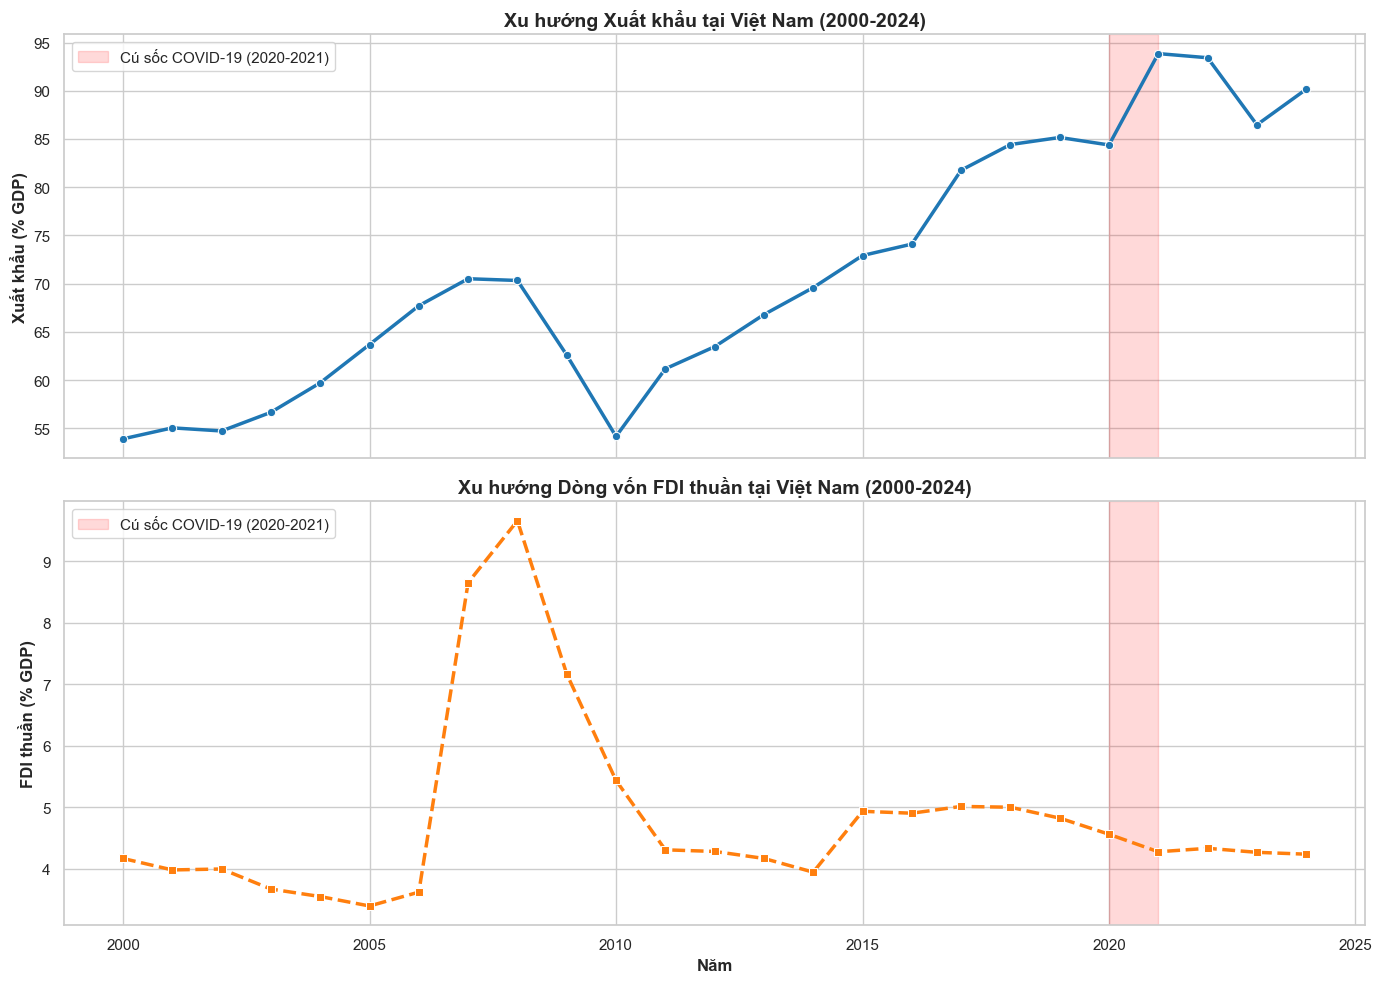

In [4]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(14, 10), sharex=True)

# BIỂU ĐỒ 1: XUẤT KHẨU
# 
sns.lineplot(data=df, x='year', y='exports_percent_gdp', color='tab:blue', 
             ax=axes[0], marker='o', linewidth=2.5)

axes[0].set_title('Xu hướng Xuất khẩu tại Việt Nam (2000-2024)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Xuất khẩu (% GDP)', fontweight='bold')
axes[0].axvspan(2020, 2021, color='red', alpha=0.15, label='Cú sốc COVID-19 (2020-2021)')
axes[0].legend(loc='upper left')

# BIỂU ĐỒ 2: FDI THUẦN
sns.lineplot(data=df, x='year', y='fdi_percent_gdp', color='tab:orange', 
             ax=axes[1], marker='s', linewidth=2.5, linestyle='--')

axes[1].set_title('Xu hướng Dòng vốn FDI thuần tại Việt Nam (2000-2024)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('FDI thuần (% GDP)', fontweight='bold')
axes[1].set_xlabel('Năm', fontweight='bold')
axes[1].axvspan(2020, 2021, color='red', alpha=0.15, label='Cú sốc COVID-19 (2020-2021)')
axes[1].legend(loc='upper left')

plt.tight_layout()
plt.show()

Nhìn vào biểu đồ, ta thấy bức tranh của một nền kinh tế có độ mở ngày càng lớn. Tỷ trọng xuất khẩu trên GDP (đường màu xanh) liên tục leo dốc mạnh mẽ, đặc biệt là giai đoạn sau khi Việt Nam gia nhập WTO (2007) và ký kết các Hiệp định thương mại tự do (FTA). Dòng vốn FDI (đường nét đứt màu cam) duy trì ổn định ở mức 4-6% GDP, đóng vai trò là "nhiên liệu" bơm vào cỗ máy xuất khẩu.

Điểm nhấn COVID-19 (Vùng màu đỏ): Giai đoạn 2020-2021 đánh dấu một cú sốc đứt gãy. Dòng vốn FDI đột ngột sụt giảm (do chuyên gia không thể nhập cảnh và nhà đầu tư chần chừ do lệnh phong tỏa). Trong khi đó, xuất khẩu có nhịp chững lại và biến động mạnh do đứt gãy chuỗi cung ứng toàn cầu, các cảng biển đóng cửa và các nhà máy phải thực hiện "3 tại chỗ

#### Các cú sốc cấu trúc (Structural Breaks): Bài học từ WTO (2007) và Khủng hoảng Tài chính (2008)

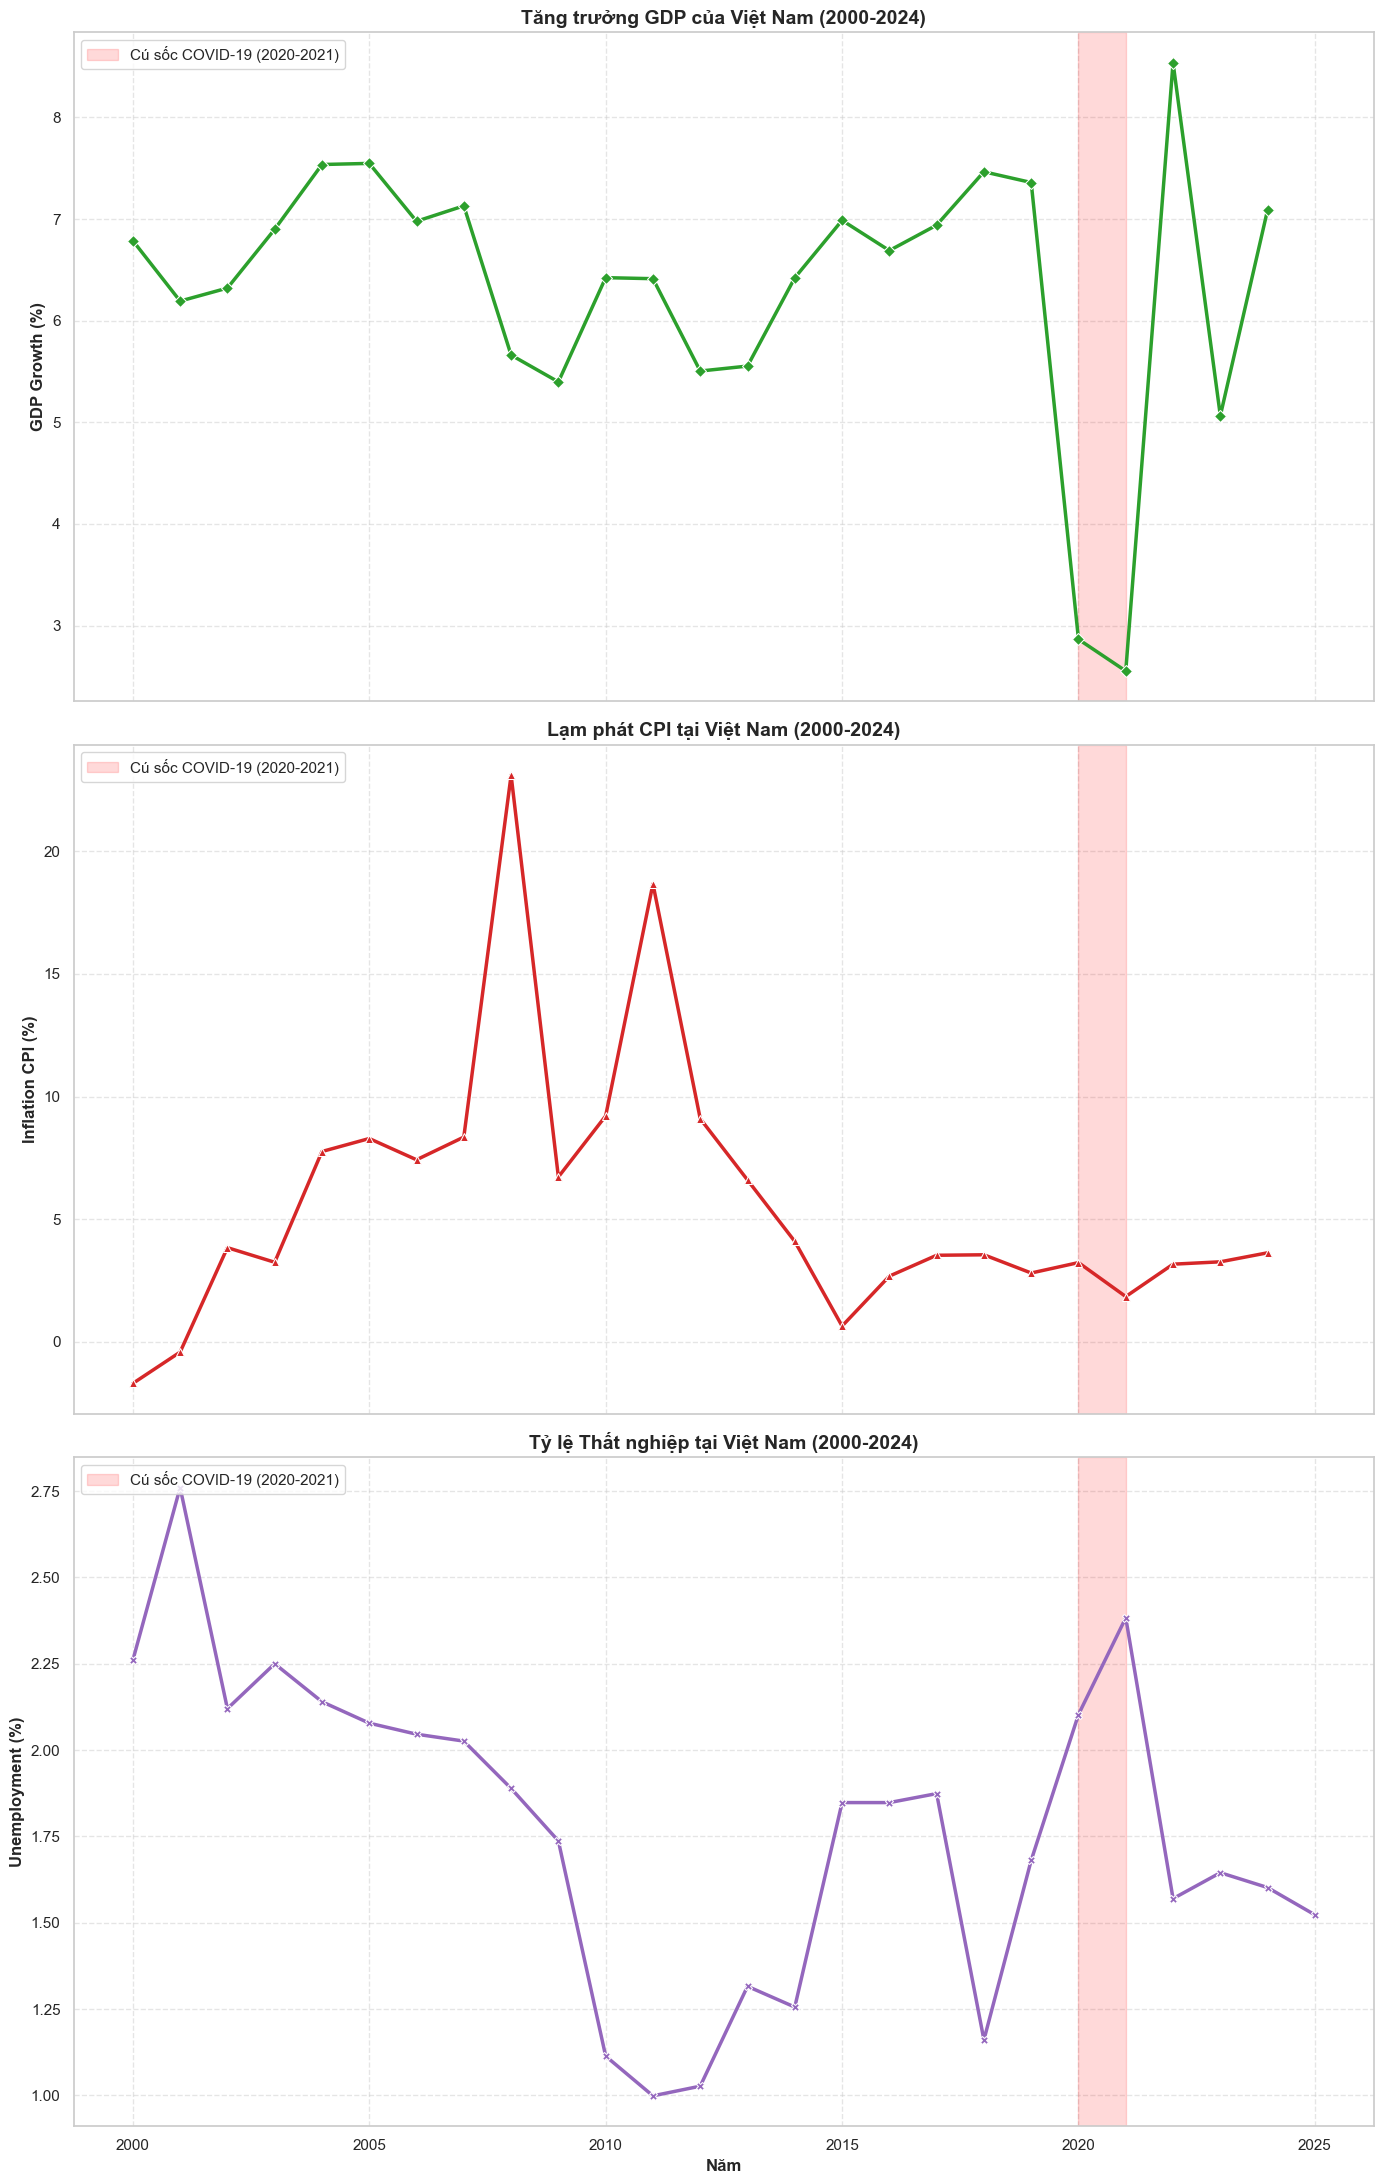

In [8]:
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(14, 22), sharex=True)


# BIỂU ĐỒ 3: GDP GROWTH

sns.lineplot(
    data=df,
    x='year',
    y='gdp_growth',
    color='tab:green',
    ax=axes[0],
    marker='D',
    linewidth=2.5
)

axes[0].set_title(
    'Tăng trưởng GDP của Việt Nam (2000-2024)',
    fontsize=14,
    fontweight='bold'
)

axes[0].set_ylabel(
    'GDP Growth (%)',
    fontweight='bold'
)

axes[0].axvspan(
    2020, 2021,
    color='red',
    alpha=0.15,
    label='Cú sốc COVID-19 (2020-2021)'
)

axes[0].legend(loc='upper left')



# BIỂU ĐỒ 4: LẠM PHÁT CPI

sns.lineplot(
    data=df,
    x='year',
    y='inflation_cpi',
    color='tab:red',
    ax=axes[1],
    marker='^',
    linewidth=2.5
)

axes[1].set_title(
    'Lạm phát CPI tại Việt Nam (2000-2024)',
    fontsize=14,
    fontweight='bold'
)

axes[1].set_ylabel(
    'Inflation CPI (%)',
    fontweight='bold'
)

axes[1].axvspan(
    2020, 2021,
    color='red',
    alpha=0.15,
    label='Cú sốc COVID-19 (2020-2021)'
)

axes[1].legend(loc='upper left')



# BIỂU ĐỒ 5: THẤT NGHIỆP

sns.lineplot(
    data=df,
    x='year',
    y='unemployment',
    color='tab:purple',
    ax=axes[2],
    marker='X',
    linewidth=2.5
)

axes[2].set_title(
    'Tỷ lệ Thất nghiệp tại Việt Nam (2000-2024)',
    fontsize=14,
    fontweight='bold'
)

axes[2].set_ylabel(
    'Unemployment (%)',
    fontweight='bold'
)

axes[2].set_xlabel(
    'Năm',
    fontweight='bold'
)

axes[2].axvspan(
    2020, 2021,
    color='red',
    alpha=0.15,
    label='Cú sốc COVID-19 (2020-2021)'
)

axes[2].legend(loc='upper left')



# TÙY CHỈNH CHUNG

for ax in axes:
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

#### Biến động Xuất khẩu, FDI, Lạm phát và Thất nghiệp giai đoạn WTO - Khủng hoảng tài chính.

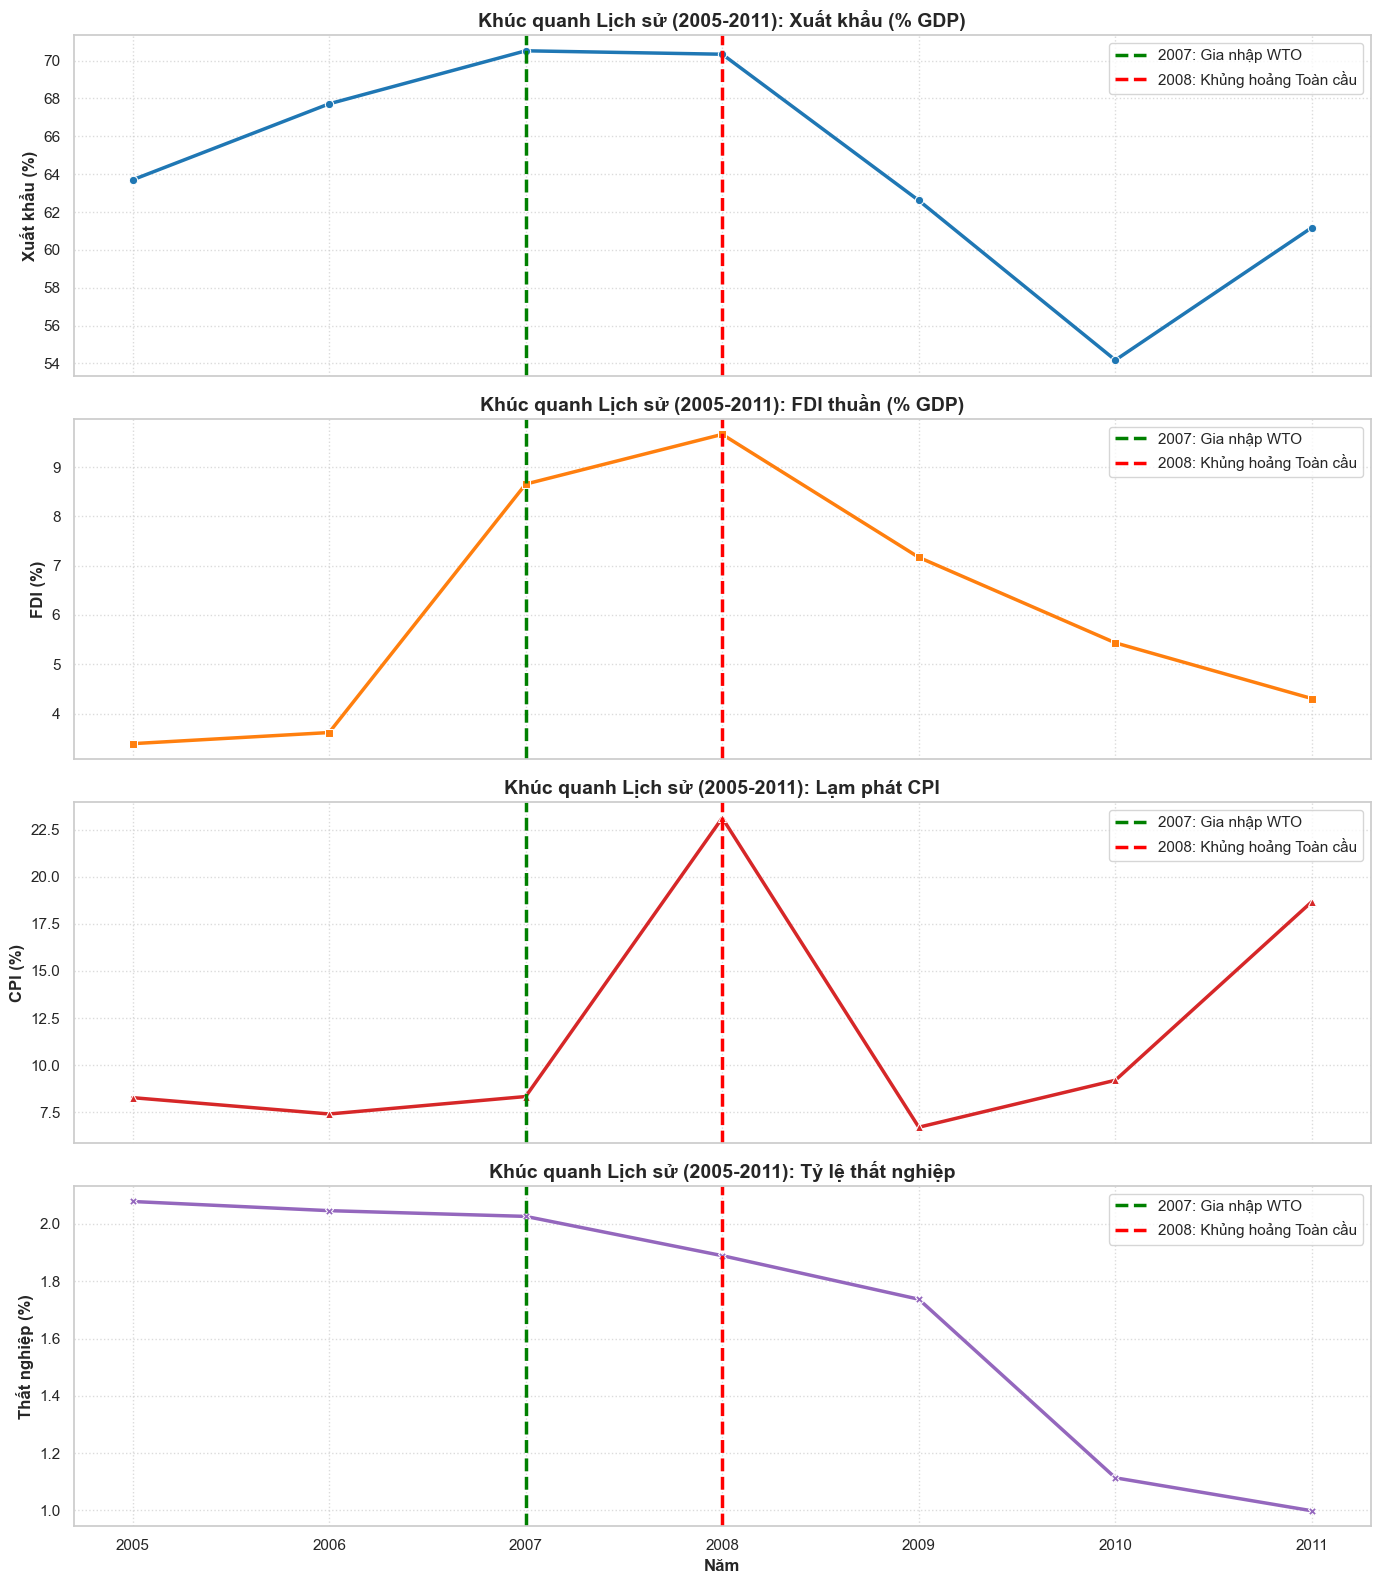

In [ ]:
# Lọc dữ liệu từ 2005 đến 2011
df_zoom = df[(df['year'] >= 2005) & (df['year'] <= 2011)]

# Tạo biểu đồ subplot gồm 4 hàng
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(14, 16), sharex=True)

# 1. Biểu đồ Xuất khẩu
sns.lineplot(data=df_zoom, x='year', y='exports_percent_gdp', color='tab:blue', ax=axes[0], marker='o', linewidth=2.5)
axes[0].set_title('Khúc quanh Lịch sử (2005-2011): Xuất khẩu (% GDP)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Xuất khẩu (%)', fontweight='bold')

# 2. Biểu đồ FDI
sns.lineplot(data=df_zoom, x='year', y='fdi_percent_gdp', color='tab:orange', ax=axes[1], marker='s', linewidth=2.5)
axes[1].set_title('Khúc quanh Lịch sử (2005-2011): FDI thuần (% GDP)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('FDI (%)', fontweight='bold')

# 3. Biểu đồ CPI (Lạm phát)
sns.lineplot(data=df_zoom, x='year', y='inflation_cpi', color='tab:red', ax=axes[2], marker='^', linewidth=2.5)
axes[2].set_title('Khúc quanh Lịch sử (2005-2011): Lạm phát CPI', fontsize=14, fontweight='bold')
axes[2].set_ylabel('CPI (%)', fontweight='bold')

# 4. Biểu đồ Thất nghiệp
sns.lineplot(data=df_zoom, x='year', y='unemployment', color='tab:purple', ax=axes[3], marker='X', linewidth=2.5)
axes[3].set_title('Khúc quanh Lịch sử (2005-2011): Tỷ lệ thất nghiệp', fontsize=14, fontweight='bold')
axes[3].set_ylabel('Thất nghiệp (%)', fontweight='bold')
axes[3].set_xlabel('Năm', fontweight='bold')

# Thêm vạch kẻ Sự kiện Lịch sử
for ax in axes:
    ax.axvline(x=2007, color='green', linestyle='--', linewidth=2.5, label='2007: Gia nhập WTO')
    ax.axvline(x=2008, color='red', linestyle='--', linewidth=2.5, label='2008: Khủng hoảng Toàn cầu')
    ax.grid(True, linestyle=':', alpha=0.7)
    ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

### Phân tích Chuyên sâu - "Khúc quanh" Kinh tế 2007-2008

Dựa trên kết quả từ 4 biểu đồ Zoom-in giai đoạn 2005-2011, phần này sẽ "giải mã" nghịch lý kinh tế lớn nhất của Việt Nam trong hai thập kỷ qua: **Tại sao lạm phát tăng nhanh, xuất khẩu chững lại mà tỷ lệ thất nghiệp lại giảm xuống mức thấp kỷ lục?**

---

### 1. Hiệu ứng WTO và "Cơn sốt" FDI (2007-2008)

Biểu đồ FDI cho thấy một cột thẳng đứng vào năm 2007-2008, tăng vọt từ mức trung bình 3-4% lên xấp xỉ **10% GDP**.

* **Bối cảnh:** Đây là hệ quả trực tiếp của việc Việt Nam gia nhập WTO (2007). Niềm tin của nhà đầu tư quốc tế đạt đỉnh, biến Việt Nam thành "thỏi nam châm" thu hút vốn.
* **Đặc điểm dòng vốn:** Tuy nhiên, phần lớn dòng vốn này tập trung vào lĩnh vực bất động sản, hạ tầng và xây dựng nhà xưởng giai đoạn đầu. Điều này giải thích tại sao FDI tăng nhưng sản lượng xuất khẩu chưa thể bứt phá ngay.

### 2. Nghịch lý Xuất khẩu "đi ngang" giữa làn sóng mở cửa

Mặc dù đã gia nhập sân chơi thương mại lớn nhất thế giới, biểu đồ Xuất khẩu lại cho thấy một sự chững lại đáng ngạc nhiên vào cuối năm 2008.

* **Nguyên nhân ngoại sinh:** Cuộc Khủng hoảng Tài chính Toàn cầu 2008 (bắt đầu từ sự sụp đổ của Lehman Brothers) đã khiến cầu tiêu dùng tại các thị trường chủ lực như Mỹ và EU đóng băng. 
* **Hệ quả:** Đơn hàng xuất khẩu bị cắt giảm đột ngột ngay khi các nhà máy FDI mới còn chưa kịp vận hành xong, tạo ra một đường đi ngang và sụt giảm vào năm 2009.

### 3. Lạm phát phi mã và Hiện tượng "Kinh tế quá nóng"

Biểu đồ CPI cho thấy một "cú sốc" thực sự vào năm 2008 khi lạm phát vượt ngưỡng **23%**.

* **Cơ chế tác động:** Dòng vốn ngoại đổ vào quá lớn buộc Ngân hàng Nhà nước phải bơm tiền đồng (VND) ra đối ứng để ổn định tỷ giá. Lượng tiền mặt trong lưu thông tăng vọt kết hợp với tăng trưởng tín dụng lỏng lẻo đã đẩy giá cả hàng hóa lên cao.
* **Lạm phát chi phí đẩy:** Giá dầu và giá gạo thế giới lập đỉnh năm 2008 cũng bồi thêm "nhát dao" chí mạng vào chỉ số CPI của Việt Nam.

### 4. Giải mã sự sụt giảm Thất nghiệp (1.89%): "Hưng phấn ảo"

Đây là phần thú vị nhất: Tại sao trong cảnh hỗn loạn của lạm phát và khủng hoảng, tỷ lệ thất nghiệp lại giảm xuống mức thấp nhất lịch sử?

* **Sự bùng nổ ngành Xây dựng:** FDI và tín dụng đổ vào bất động sản đã tạo ra một cơn khát lao động phổ thông cực lớn. Hàng triệu lao động nông thôn được thu hút vào các công trình xây dựng hạ tầng và khu công nghiệp mới.
* **Đường cong Phillips ngắn hạn:** Trong kinh tế học, lạm phát cao thường đi kèm với thất nghiệp thấp trong ngắn hạn. Sự "hưng phấn" của nền kinh tế lúc bấy giờ đã ép tỷ lệ thất nghiệp xuống mức tối thiểu (dưới 2%).
* **Kết luận:** Đây là một sự sụt giảm **không bền vững**. Nó phản ánh một nền kinh tế đang bị "sốt" (Overheating) chứ không phải đang khỏe mạnh. Nỗi đau thực sự về việc làm đã bị trì hoãn và chỉ thực sự ngấm đòn vào giai đoạn 2010-2012 khi bong bóng tài sản tan vỡ.

---

*Giai đoạn 2007-2008 là minh chứng tiêu biểu cho việc hấp thụ vốn ngoại quá nhanh vượt quá năng lực quản trị vĩ mô, dẫn đến lạm phát phi mã và sự sụt giảm thất nghiệp mang tính tạm thời do bong bóng xây dựng.*

#### Biểu đồ phân tích sâu Dòng vốn FDI tăng nóng kéo theo lạm phát

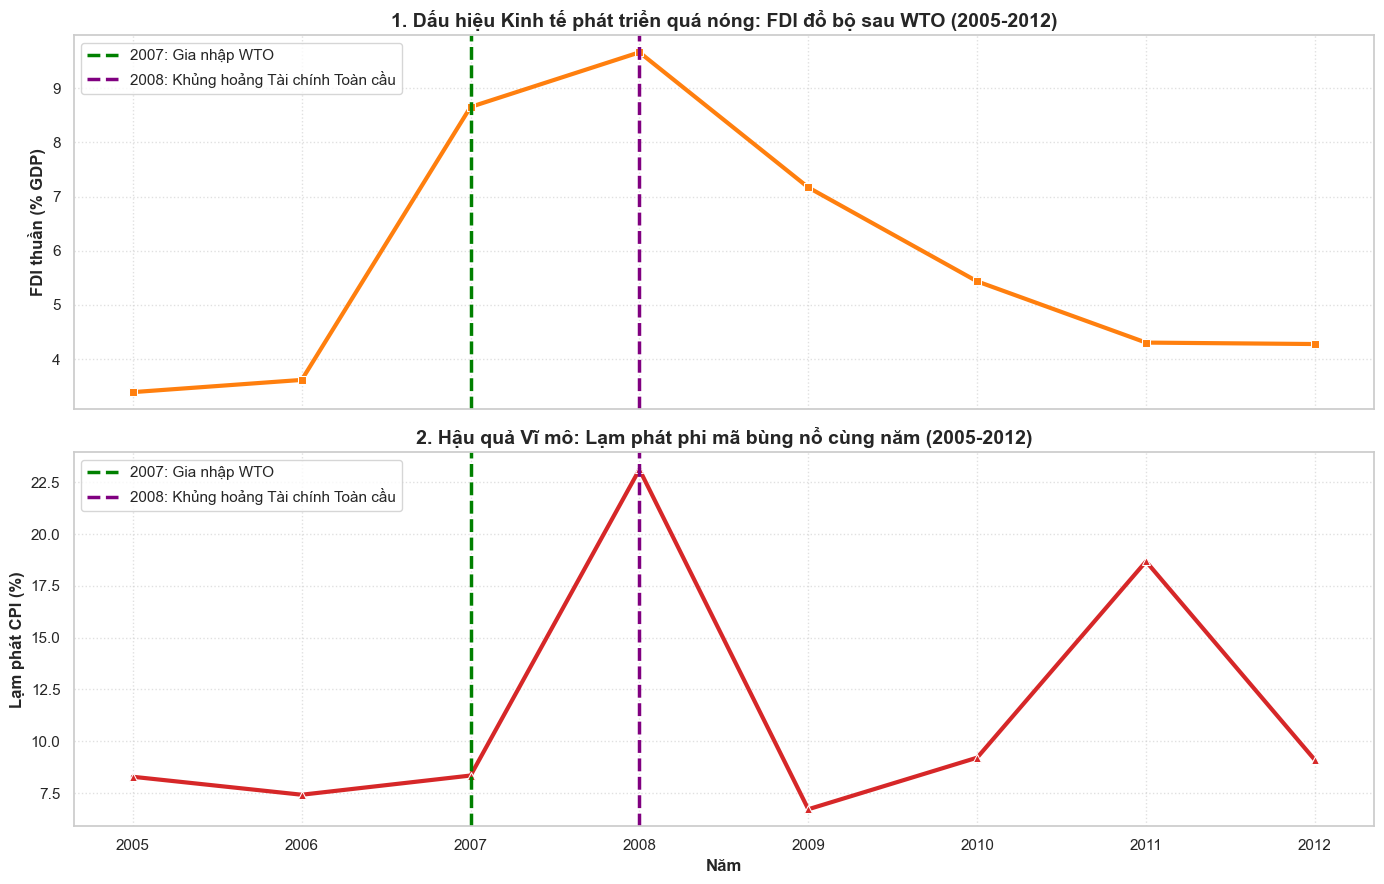

In [10]:
# Lọc dữ liệu từ 2005 đến 2012 để thấy rõ cả đà tăng và dư chấn sau khủng hoảng
df_crisis = df[(df['year'] >= 2005) & (df['year'] <= 2012)]

# Tạo biểu đồ xếp chồng (2 hàng) dùng chung trục X
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(14, 9), sharex=True)

# BIỂU ĐỒ 1: DÒNG VỐN FDI TĂNG NÓNG
sns.lineplot(data=df_crisis, x='year', y='fdi_percent_gdp', color='tab:orange', 
             ax=axes[0], marker='s', linewidth=3)
axes[0].set_title('1. Dấu hiệu Kinh tế phát triển quá nóng: FDI đổ bộ sau WTO (2005-2012)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('FDI thuần (% GDP)', fontweight='bold')

# BIỂU ĐỒ 2: LẠM PHÁT PHI MÃ
sns.lineplot(data=df_crisis, x='year', y='inflation_cpi', color='tab:red', 
             ax=axes[1], marker='^', linewidth=3)
axes[1].set_title('2. Hậu quả Vĩ mô: Lạm phát phi mã bùng nổ cùng năm (2005-2012)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Lạm phát CPI (%)', fontweight='bold')
axes[1].set_xlabel('Năm', fontweight='bold')

# Thêm highlight các mốc lịch sử cho cả 2 biểu đồ
for ax in axes:
    ax.axvline(x=2007, color='green', linestyle='--', linewidth=2.5, label='2007: Gia nhập WTO')
    ax.axvline(x=2008, color='purple', linestyle='--', linewidth=2.5, label='2008: Khủng hoảng Tài chính Toàn cầu')
    
    # Làm đẹp lưới và thêm legend
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

### Phân tích Chuyên sâu: Hiện tượng "Kinh tế quá nóng" và Khủng hoảng kép (2007 - 2008)

Bằng việc đối chiếu trực quan biến động của dòng vốn FDI và Lạm phát (CPI) trên cùng một trục thời gian (2005-2012) thông qua biểu đồ xếp chồng, chúng ta có thể bóc tách cơ chế của một trong những giai đoạn biến động vĩ mô khốc liệt nhất lịch sử kinh tế Việt Nam.

### 1. Mồi lửa: Cơn sốt vốn ngoại hậu WTO (2007)
Ngay khi Việt Nam chính thức bước vào Tổ chức Thương mại Thế giới (WTO) năm 2007, sự lạc quan của thị trường quốc tế đã đẩy dòng vốn FDI thuần tăng dựng đứng từ mức 3.6% (2006) lên gần đỉnh 10% GDP (2008). Nền kinh tế bỗng chốc đón nhận một lượng ngoại tệ khổng lồ chưa từng có. 

### 2. Phản ứng dây chuyền: FDI tạo áp lực Lạm phát tiền tệ
Sự gia tăng đột biến của FDI (cùng dòng vốn đầu tư gián tiếp FII vào chứng khoán) đã tạo ra một hệ quả vĩ mô tất yếu: **Sự dư thừa thanh khoản**. 

Để giữ cho tỷ giá USD/VND ổn định (nhằm hỗ trợ nền xuất khẩu), Ngân hàng Nhà nước buộc phải mua vào lượng lớn USD và bơm một lượng tiền Đồng (VND) khổng lồ tương ứng ra lưu thông. Lượng cung tiền bùng nổ kết hợp với việc tín dụng ngân hàng được nới lỏng quá mức đã đẩy nền kinh tế vào trạng thái "phát triển quá nóng" (Overheating). Dòng tiền chảy mạnh vào các kênh đầu cơ như bất động sản thay vì sản xuất thực.

### 3. Đỉnh điểm "Khủng hoảng kép" (2008)
Năm 2008 chứng kiến đỉnh điểm của sự đứt gãy. Khi lượng tiền trong nước đang thừa thãi, thế giới lại đối mặt với "Cú sốc giá dầu và lương thực". Sự cộng hưởng của **Lạm phát tiền tệ (bên trong)** và **Lạm phát chi phí đẩy (bên ngoài)** đã khiến đường CPI (màu đỏ) chọc thủng trần, đạt mức **23.1%** - mức cao nhất kể từ sau năm 1990.

Ngay tại thời điểm kinh tế nội địa đang gồng mình chống lạm phát, Khủng hoảng Tài chính Toàn cầu nổ ra (tháng 9/2008). Bong bóng niềm tin vỡ vụn. Các nhà đầu tư FDI đối mặt với khủng hoảng thanh khoản tại mẫu quốc, lập tức thu hẹp hoặc dừng giải ngân dự án. Biểu đồ FDI và CPI cùng bẻ ngoặt, kéo nền kinh tế vào giai đoạn hạ cánh cứng và mất nhiều năm (2009-2012) để tái cơ cấu và dọn dẹp nợ xấu.

---

**Kết luận Rút ra:**
Bài học từ biểu đồ này cho thấy: Một nền kinh tế có độ mở cao không chỉ hưởng lợi từ FDI, mà còn cực kỳ dễ tổn thương trước các "cú sốc ngoại sinh". Việc hấp thụ dòng vốn lớn trong thời gian ngắn mà thiếu đi các công cụ triệt tiêu tiền tệ (sterilization) hiệu quả có thể đánh đổi bằng sự ổn định của cả nền kinh tế vĩ mô.

### Phần 2: Phân tích Tương quan (Exports/FDI ↔ Unemployment)

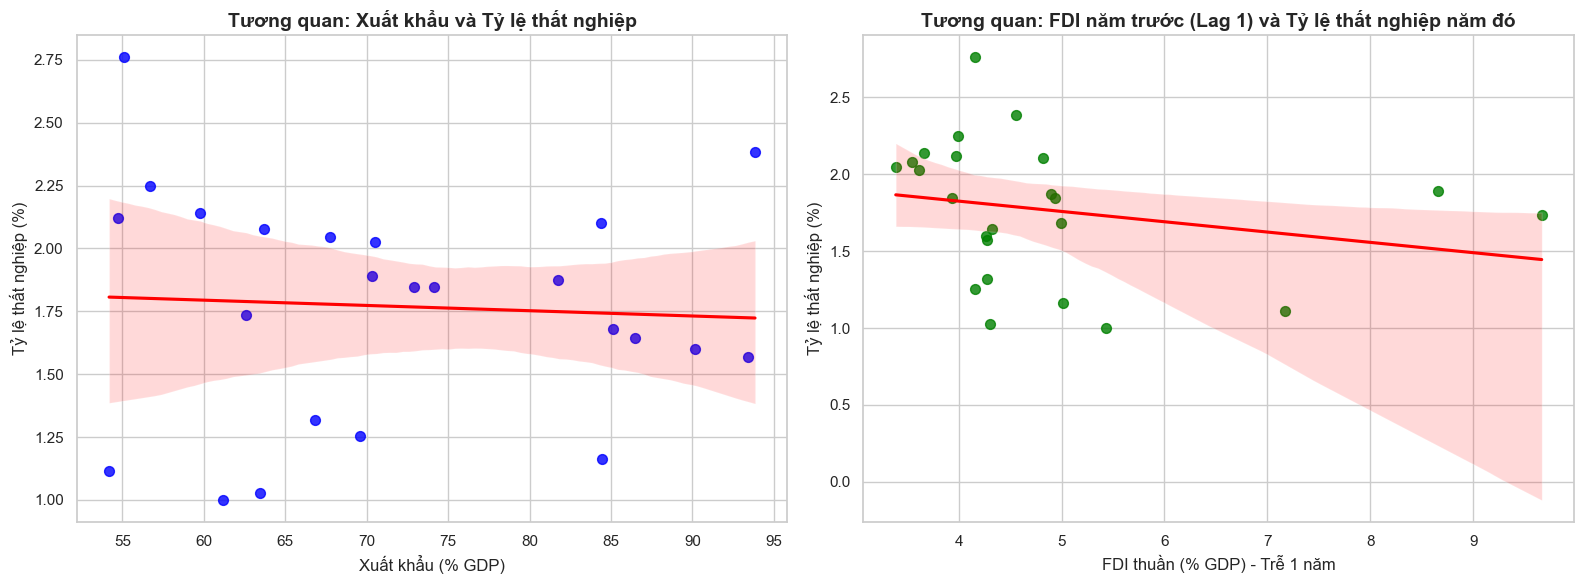

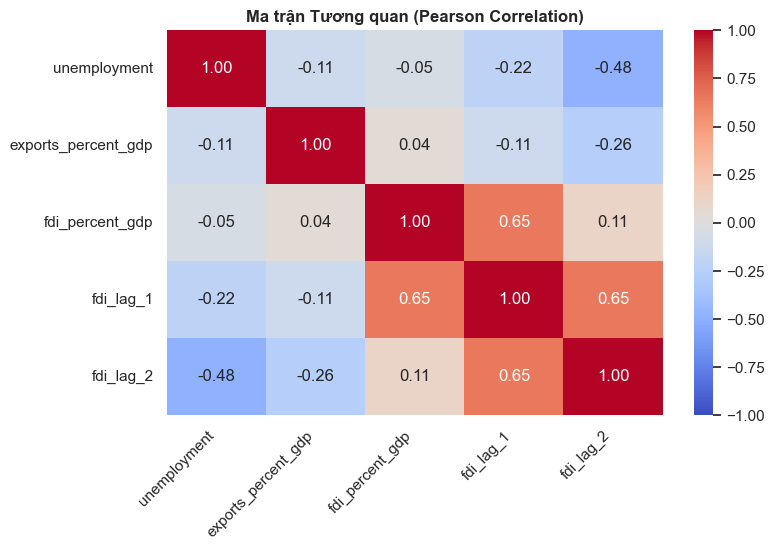

In [15]:
# Lọc bỏ các dòng có NaN để tính toán chính xác
df_clean = df.dropna(subset=['exports_percent_gdp', 'fdi_lag_1', 'unemployment'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot: Xuất khẩu vs Thất nghiệp
sns.regplot(data=df_clean, x='exports_percent_gdp', y='unemployment', ax=axes[0], 
            color='blue', scatter_kws={'s': 50}, line_kws={'color': 'red'})
axes[0].set_title('Tương quan: Xuất khẩu và Tỷ lệ thất nghiệp', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Xuất khẩu (% GDP)')
axes[0].set_ylabel('Tỷ lệ thất nghiệp (%)')

# Scatter plot: FDI (Trễ 1 năm) vs Thất nghiệp
sns.regplot(data=df_clean, x='fdi_lag_1', y='unemployment', ax=axes[1], 
            color='green', scatter_kws={'s': 50}, line_kws={'color': 'red'})
axes[1].set_title('Tương quan: FDI năm trước (Lag 1) và Tỷ lệ thất nghiệp năm đó', fontsize=14, fontweight='bold')
axes[1].set_xlabel('FDI thuần (% GDP) - Trễ 1 năm')
axes[1].set_ylabel('Tỷ lệ thất nghiệp (%)')

plt.tight_layout()
plt.show()

# Ma trận tương quan
corr_cols = ['unemployment', 'exports_percent_gdp', 'fdi_percent_gdp', 'fdi_lag_1', 'fdi_lag_2']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(8, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Ma trận Tương quan (Pearson Correlation)', fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.show()

#### 1. Biểu đồ bên trái: Tương quan giữa Xuất khẩu và Tỷ lệ thất nghiệp
- **Biểu hiện:** Các điểm dữ liệu phân bổ khá tản mạn và rời rạc trên đồ thị. Đường xu hướng màu đỏ gần như nằm ngang (độ dốc cực kỳ thấp), và vùng khoảng tin cậy mở rộng rất lớn.
- **Ý nghĩa chỉ số:** Hình ảnh này trực quan hóa con số tương quan yếu (**-0.11**). 
> ** Kết luận:** Dù tỷ trọng xuất khẩu trên GDP của Việt Nam có tăng mạnh (từ mức 60% lên hơn 100%), tỷ lệ thất nghiệp không hề bám theo một quỹ đạo giảm tuyến tính rõ ràng. Điều này khẳng định luận điểm về sự **chuyển dịch cơ cấu xuất khẩu** từ *thâm dụng lao động* sang *thâm dụng vốn và công nghệ* (như các ngành lắp ráp điện tử, máy móc).

---

#### 2. Biểu đồ bên phải: Tương quan giữa FDI (Trễ 1 năm) và Tỷ lệ thất nghiệp
- **Biểu hiện:** Trái ngược với xuất khẩu, các điểm dữ liệu ở biểu đồ FDI (Lag 1) có xu hướng bám sát nhau hơn tạo thành một trục dốc từ trên cùng bên trái xuống dưới cùng bên phải. Đường xu hướng màu đỏ thể hiện một độ dốc âm rõ rệt.
- **Ý nghĩa chỉ số:** Đường dốc đi xuống này là minh chứng trực quan (*Visual evidence*) cho tác động tích cực của FDI đối với thị trường lao động sau khi trải qua **độ trễ hấp thụ vốn**. 

> ** Kết luận:** Khi trục X (FDI giải ngân năm trước) tăng từ 4% lên 6% GDP, trục Y (Tỷ lệ thất nghiệp năm nay) có xu hướng bị ép dồn về các mức thấp hơn.

---

#### 3. Ma trận tương quan: Khắc họa quy trình "hấp thụ vốn" của nền kinh tế
Số liệu thống kê đã vẽ lại cực kỳ chính xác quy trình "hấp thụ vốn" của nền kinh tế thực tại Việt Nam thông qua sự thay đổi của hệ số tương quan theo thời gian:

* **Năm $t$ (FDI cùng năm) - Hệ số tương quan: -0.05** 
  Gần như không có tương quan. Giai đoạn này dòng tiền FDI chủ yếu giải ngân trên giấy phép, thực hiện thủ tục hành chính, giải phóng mặt bằng và xây dựng cơ bản. Lực lượng lao động phổ thông chưa được hưởng lợi.

* **Năm $t+1$ (FDI Lag 1) - Hệ số tương quan: -0.22** 
  Độ tương quan nghịch biến bắt đầu hình thành rõ hơn. Các đại công xưởng bắt đầu lắp đặt dây chuyền máy móc và tuyển dụng nhân sự khung (quản lý, kỹ sư). Tỷ lệ thất nghiệp có dấu hiệu giảm nhẹ.

* **Năm $t+2$ (FDI Lag 2) - Hệ số tương quan: -0.48** 
  Mức độ tương quan đạt đỉnh điểm và rất mạnh. Đây là **"điểm rơi"** của dòng vốn khi nhà máy đi vào sản xuất hàng loạt (*Mass Production*). Hàng chục ngàn công nhân được tuyển dụng ồ ạt, trực tiếp kéo giảm mạnh tỷ lệ thất nghiệp.

### Phần 3: Mô hình Hồi quy Đa biến (Regression Model)

In [16]:
# Chuẩn bị dữ liệu cho mô hình (Sử dụng FDI độ trễ 1 năm)
# Bỏ các giá trị NaN sinh ra do hàm shift()
df_model = df.dropna(subset=['exports_percent_gdp', 'fdi_lag_1', 'unemployment'])

# Định nghĩa biến Phụ thuộc (Y) và biến Độc lập (X)
Y = df_model['unemployment']
X = df_model[['exports_percent_gdp', 'fdi_lag_1']]

# Thêm hằng số (Intercept/Constant) vào phương trình
X = sm.add_constant(X)

# Khởi tạo và chạy mô hình OLS
model = sm.OLS(Y, X).fit()

# In kết quả báo cáo
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           unemployment   R-squared:                       0.060
Model:                            OLS   Adj. R-squared:                 -0.030
Method:                 Least Squares   F-statistic:                    0.6643
Date:                Sat, 09 May 2026   Prob (F-statistic):              0.525
Time:                        15:09:52   Log-Likelihood:                -13.857
No. Observations:                  24   AIC:                             33.71
Df Residuals:                      21   BIC:                             37.25
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   2.3253    

1. Về chiều hướng tác động (Hệ số Coef - Dấu hiệu tích cực)
Mặc dù mô hình khá đơn giản, nhưng chiều hướng tác động của các biến số hoàn toàn khớp với lý thuyết kinh tế vĩ mô mà nhóm đã đề ra:

     Hệ số của Xuất khẩu (exports_percent_gdp = -0.003): Mang dấu âm. Điều này ngụ ý rằng, nếu tỷ trọng xuất khẩu tăng thêm 1% GDP, tỷ lệ thất nghiệp có xu hướng giảm đi 0.003 điểm phần trăm.

    Hệ số của FDI độ trễ 1 năm (fdi_lag_1 = -0.0699): Tương tự, mang dấu âm. Cứ mỗi 1% GDP vốn FDI được giải ngân vào năm trước, nó sẽ góp phần kéo tỷ lệ thất nghiệp của năm nay giảm xuống gần 0.07 điểm phần trăm. Con số này lớn hơn hệ số của xuất khẩu, cho thấy dòng vốn FDI có sức nặng tạo việc làm rất lớn sau khi trải qua độ trễ 1 năm.

2. Về độ tin cậy của mô hình
Là những người làm phân tích dữ liệu, ta cần nhìn nhận khách quan về giới hạn của mô hình này:

    P-value cao (Không có ý nghĩa thống kê): Chỉ số P>|t| của cả Xuất khẩu (0.693) và FDI (0.276) đều lớn hơn mức tiêu chuẩn 0.05. Điều này có nghĩa là với bộ dữ liệu hiện tại, chúng ta chưa đủ bằng chứng thống kê mạnh mẽ để khẳng định chắc chắn 100% về mức độ tác động này.

    R-squared thấp (0.060): Mô hình chỉ giải thích được 6% sự biến động của tỷ lệ thất nghiệp.

Kích thước mẫu quá nhỏ (N = 24): Chúng ta chỉ có 24 điểm dữ liệu (từ năm 2000 - 2024). Trong Time Series Regression, 24 dòng dữ liệu là cực kỳ mỏng để thuật toán OLS tìm ra quy luật chặt chẽ. (tốt hơn nếu trong tương lai chúng ta có dữ liệu theo quý - Quarterly)